# 02B — Exploratory Data Analysis (EDA)
### QM640 Capstone | Kunal Mishra

Sits between `02_DATA_CLEANING` and `03_FEATURE_ENGINEERING`.
All charts are saved to `data/plots/` so they can be referenced in the interim report.

**Reads from:** `data/clean/`  
**Writes to:** `data/plots/`

| Section | What it covers |
|---|---|
| 1 | Setup and data load |
| 2 | Target variable distribution |
| 3 | Return distributions and fat tails |
| 4 | Cross-market correlation |
| 5 | Fear & Greed Index over time |
| 6 | Google Trends SVI over time |
| 7 | Macroeconomic series |
| 8 | Feature correlations with target |
| 9 | Regime analysis (VIX and market stress) |
| 10 | EDA summary table |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import json, warnings, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
warnings.filterwarnings('ignore')

with open('/content/drive/MyDrive/CapstoneDA/config.json') as f:
    CFG = json.load(f)

CLEAN = CFG['PATHS']['clean']
PLOTS = CFG['PATHS']['plots']
os.makedirs(PLOTS, exist_ok=True)

# Consistent style for all charts
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'legend.fontsize'   : 9,
})

BLUE   = '#1565C0'
GREEN  = '#00897B'
RED    = '#C62828'
ORANGE = '#E65100'
GREY   = '#546E7A'
GOLD   = '#F9A825'

print('Setup complete.')
print(f'Reading from : {CLEAN}')
print(f'Saving plots : {PLOTS}')

Mounted at /content/drive
Setup complete.
Reading from : /content/drive/MyDrive/CapstoneDA/data/clean
Saving plots : /content/drive/MyDrive/CapstoneDA/data/plots


In [2]:
def load(path, label):
    df = pd.read_csv(path, index_col='Date', parse_dates=['Date'])
    if hasattr(df.index,'tz') and df.index.tz is not None:
        df.index = df.index.tz_convert(None)
    print(f'  {label:35} {len(df):>5} rows  '
          f'{df.index.min().date()} to {df.index.max().date()}')
    return df

print('Loading clean data:')
sp500  = load(f'{CLEAN}/sp500_clean.csv',       'S&P 500 prices')
nifty  = load(f'{CLEAN}/nifty_clean.csv',       'NIFTY 50 prices')
macro  = load(f'{CLEAN}/macro_clean.csv',        'Macro (FRED)')
fg     = load(f'{CLEAN}/fear_greed_clean.csv',  'Fear & Greed')
svi_us = load(f'{CLEAN}/svi_sp500_daily.csv',   'SVI S&P 500 (daily)')
svi_in = load(f'{CLEAN}/svi_nifty_daily.csv',   'SVI NIFTY 50 (daily)')

# Compute daily log returns
sp500['log_ret'] = np.log(sp500['close'] / sp500['close'].shift(1))
nifty['log_ret'] = np.log(nifty['close'] / nifty['close'].shift(1))

# Target variable: next-day direction
sp500['Target_Dir'] = (sp500['close'].shift(-1) > sp500['close']).astype(int)
nifty['Target_Dir'] = (nifty['close'].shift(-1) > nifty['close']).astype(int)
sp500 = sp500.iloc[:-1].copy()
nifty = nifty.iloc[:-1].copy()

print(f'\nLog returns and target variable created.')
print(f'  S&P 500 up-day rate : {sp500["Target_Dir"].mean():.1%}')
print(f'  NIFTY 50 up-day rate: {nifty["Target_Dir"].mean():.1%}')

Loading clean data:
  S&P 500 prices                       2513 rows  2016-01-04 to 2025-12-30
  NIFTY 50 prices                      2463 rows  2016-01-04 to 2025-12-30
  Macro (FRED)                         2608 rows  2016-01-04 to 2025-12-31
  Fear & Greed                         2609 rows  2016-01-01 to 2025-12-31
  SVI S&P 500 (daily)                  2513 rows  2016-01-04 to 2025-12-30
  SVI NIFTY 50 (daily)                 2463 rows  2016-01-04 to 2025-12-30

Log returns and target variable created.
  S&P 500 up-day rate : 54.8%
  NIFTY 50 up-day rate: 54.2%


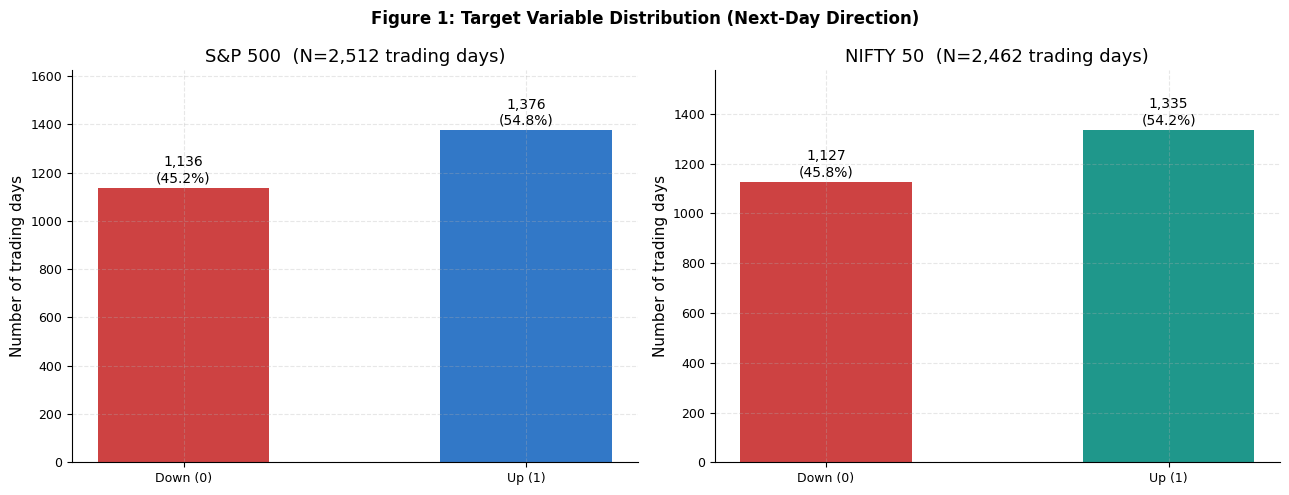

Key insight: Both markets have nearly equal up/down day rates.
This confirms the naive majority-class baseline accuracy is ~53-54%,
making AUC and F1 more informative metrics than raw accuracy.


In [3]:
# Figure 1: Target variable distribution
# Shows how balanced the classification problem is.
# A near-50/50 split means naive accuracy is not a reliable metric.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 1: Target Variable Distribution (Next-Day Direction)', fontweight='bold')

for ax, df, label, color in [
    (axes[0], sp500, 'S&P 500', BLUE),
    (axes[1], nifty, 'NIFTY 50', GREEN),
]:
    counts = df['Target_Dir'].value_counts().sort_index()
    labels = ['Down (0)', 'Up (1)']
    bars   = ax.bar(labels, counts.values,
                    color=[RED, color], width=0.5, alpha=0.88)

    for bar, val in zip(bars, counts.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 10,
                f'{val:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=10)

    ax.set_title(f'{label}  (N={len(df):,} trading days)')
    ax.set_ylabel('Number of trading days')
    ax.set_ylim(0, counts.max() * 1.18)

plt.tight_layout()
plt.savefig(f'{PLOTS}/eda_01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key insight: Both markets have nearly equal up/down day rates.')
print('This confirms the naive majority-class baseline accuracy is ~53-54%,')
print('making AUC and F1 more informative metrics than raw accuracy.')

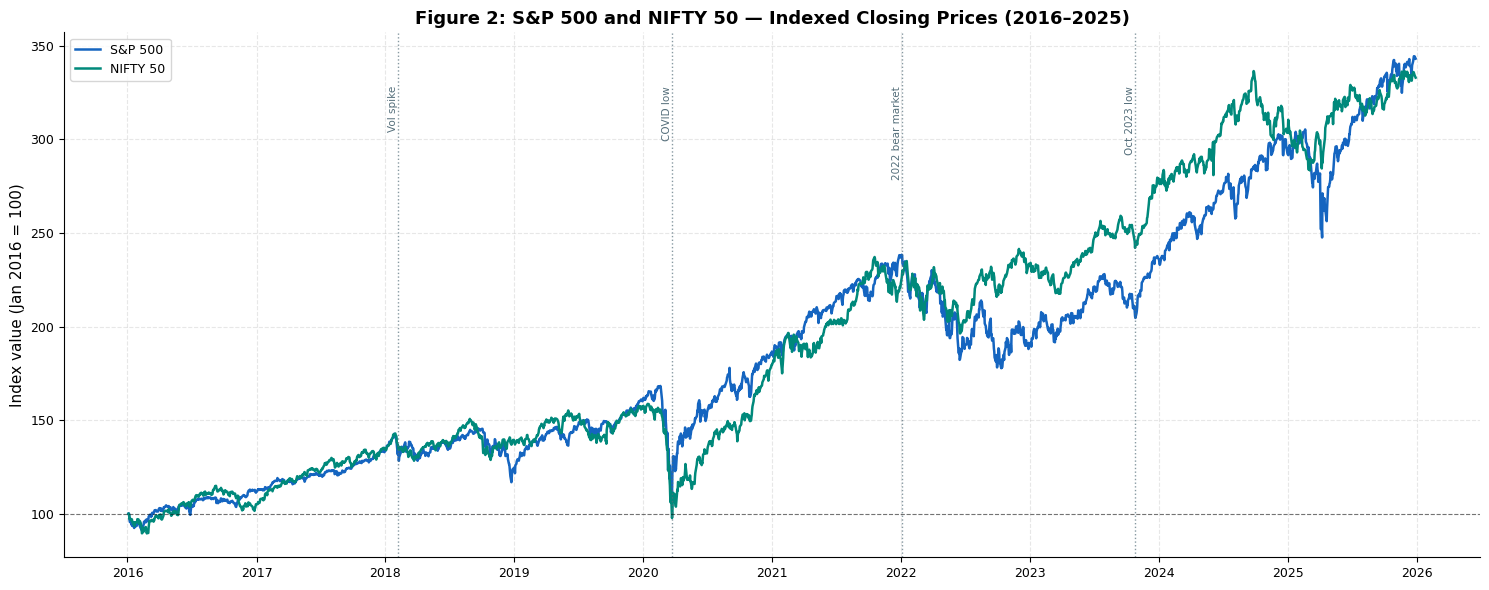

Total return 2016-2025:
  S&P 500 : 243.1%
  NIFTY 50: 233.0%


In [4]:
# Figure 2: Indexed closing prices (rebased to 100)
# Shows the growth trajectory and key market events over 2016-2025.

fig, ax = plt.subplots(figsize=(15, 6))

sp_norm = (sp500['close'] / sp500['close'].iloc[0]) * 100
ni_norm = (nifty['close'] / nifty['close'].iloc[0]) * 100

ax.plot(sp_norm.index, sp_norm.values, color=BLUE,  linewidth=1.8, label='S&P 500')
ax.plot(ni_norm.index, ni_norm.values, color=GREEN, linewidth=1.8, label='NIFTY 50')

# Annotate key market events
events = [
    ('2018-02-05', 'Vol spike'),
    ('2020-03-23', 'COVID low'),
    ('2022-01-03', '2022 bear market'),
    ('2023-10-27', 'Oct 2023 low'),
]
for date_str, label in events:
    dt = pd.Timestamp(date_str)
    if dt in sp_norm.index:
        y  = sp_norm.loc[dt]
        ax.axvline(dt, color=GREY, linestyle=':', linewidth=1, alpha=0.7)
        ax.text(dt, ax.get_ylim()[1]*0.92 if ax.get_ylim()[1] > 0 else 350,
                label, fontsize=7.5, rotation=90,
                color=GREY, va='top', ha='right')

ax.axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Index value (Jan 2016 = 100)')
ax.set_title('Figure 2: S&P 500 and NIFTY 50 — Indexed Closing Prices (2016–2025)',
             fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(f'{PLOTS}/eda_02_indexed_prices.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total return 2016-2025:')
print(f'  S&P 500 : {sp_norm.iloc[-1]-100:.1f}%')
print(f'  NIFTY 50: {ni_norm.iloc[-1]-100:.1f}%')

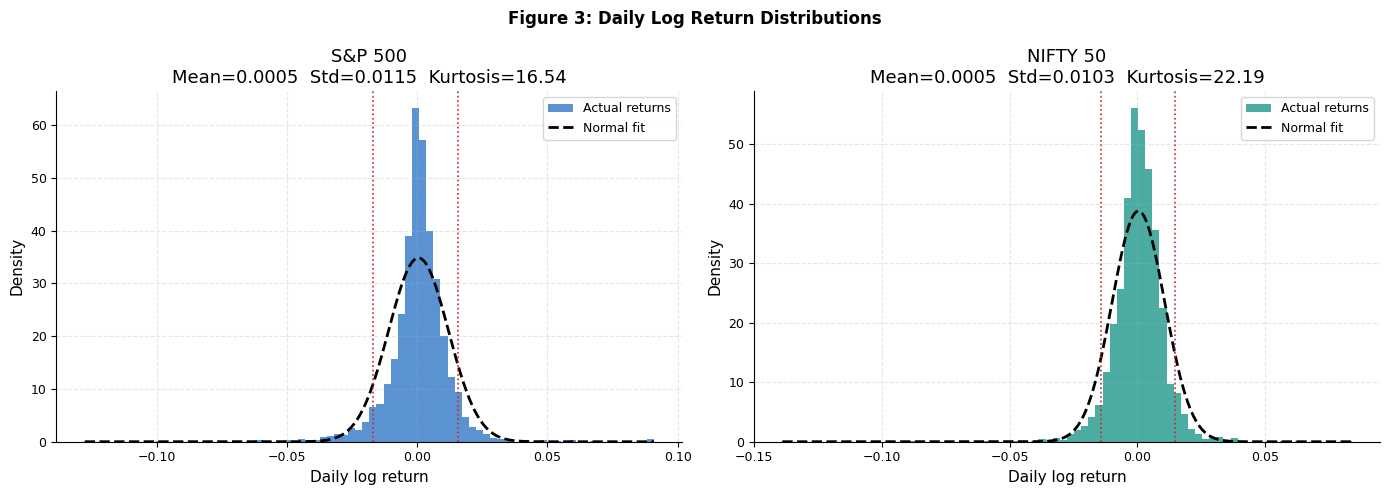

Key insight: Both distributions are leptokurtic (fat tails).
  S&P 500 excess kurtosis: 16.54  (Normal = 0)
  NIFTY 50 excess kurtosis: 22.19
Fat tails mean that on rare extreme days, losses/gains are much larger
than a normal distribution would predict. This is why the backtest
strategy loses money even with correct directional calls during the 2022 bear market.


In [5]:
# Figure 3: Daily log return distributions
# Fat tails matter for backtesting — extreme returns break simple strategies.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 3: Daily Log Return Distributions', fontweight='bold')

for ax, df, label, color in [
    (axes[0], sp500, 'S&P 500', BLUE),
    (axes[1], nifty, 'NIFTY 50', GREEN),
]:
    ret = df['log_ret'].dropna()

    ax.hist(ret, bins=80, color=color, alpha=0.7,
            density=True, label='Actual returns')

    # Overlay normal distribution
    mu, sigma = ret.mean(), ret.std()
    x = np.linspace(ret.min(), ret.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma),
            color='black', linewidth=2, linestyle='--', label='Normal fit')

    kurt = stats.kurtosis(ret)
    ax.set_title(f'{label}\n'
                 f'Mean={mu:.4f}  Std={sigma:.4f}  '
                 f'Kurtosis={kurt:.2f}')
    ax.set_xlabel('Daily log return')
    ax.set_ylabel('Density')
    ax.legend()

    # Mark 5th and 95th percentile
    p5, p95 = ret.quantile(0.05), ret.quantile(0.95)
    ax.axvline(p5,  color=RED, linestyle=':', linewidth=1.2,
               label=f'5th pct={p5:.3f}')
    ax.axvline(p95, color=RED, linestyle=':', linewidth=1.2,
               label=f'95th pct={p95:.3f}')

plt.tight_layout()
plt.savefig(f'{PLOTS}/eda_03_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

sp_kurt = stats.kurtosis(sp500['log_ret'].dropna())
ni_kurt = stats.kurtosis(nifty['log_ret'].dropna())
print('Key insight: Both distributions are leptokurtic (fat tails).')
print(f'  S&P 500 excess kurtosis: {sp_kurt:.2f}  (Normal = 0)')
print(f'  NIFTY 50 excess kurtosis: {ni_kurt:.2f}')
print('Fat tails mean that on rare extreme days, losses/gains are much larger')
print('than a normal distribution would predict. This is why the backtest')
print('strategy loses money even with correct directional calls during the 2022 bear market.')

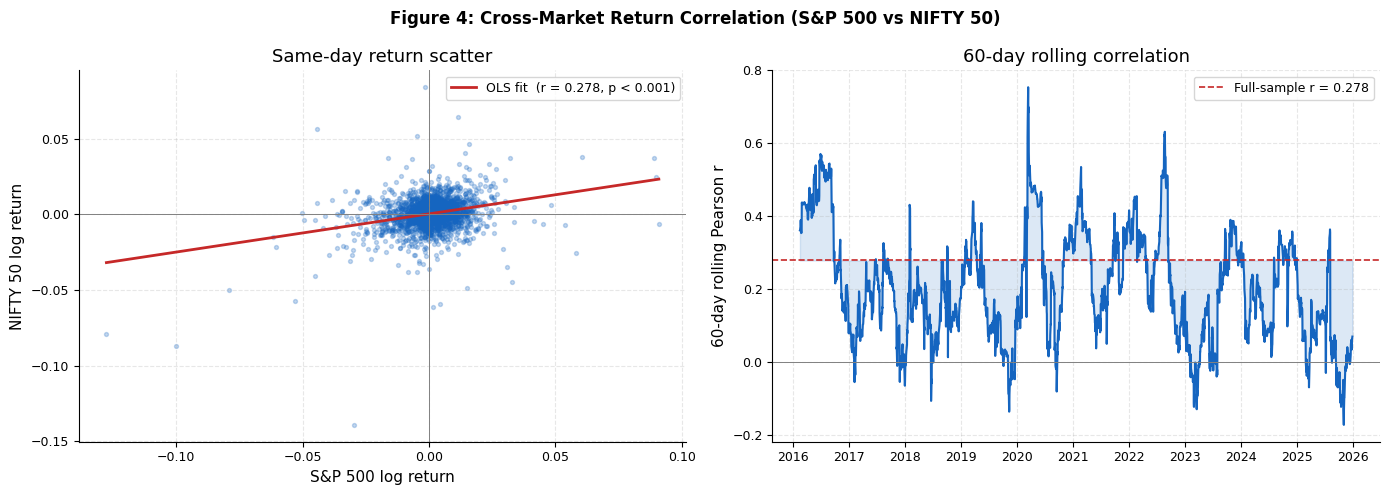

Full-sample Pearson r = 0.278  (p < 0.001 given N=2388)
Key insight: Moderate positive correlation means common global factors exist,
but the two markets are not perfectly synchronised. Market-specific signals
(USDINR, local SVI, FG_t1 lag) carry information beyond this shared component.

Note: NIFTY closes 10 hours BEFORE S&P 500. The scatter uses same-calendar-day
returns, but NIFTY already closed before the US opened on those days.
This is exactly why SP500_t1_Ret (prior day) is used in NIFTY models.


In [6]:
# Figure 4: Cross-market return correlation
# How correlated are the two markets on a same-day basis?

# Align on common trading dates
common_idx = sp500.index.intersection(nifty.index)
sp_ret = sp500.loc[common_idx, 'log_ret'].dropna()
ni_ret = nifty.loc[common_idx, 'log_ret'].reindex(sp_ret.index)
both   = pd.DataFrame({'SP500': sp_ret, 'NIFTY50': ni_ret}).dropna()

pearson_r, p_val = stats.pearsonr(both['SP500'], both['NIFTY50'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 4: Cross-Market Return Correlation (S&P 500 vs NIFTY 50)',
             fontweight='bold')

# Scatter
ax = axes[0]
ax.scatter(both['SP500'], both['NIFTY50'],
           alpha=0.25, s=8, color=BLUE)
m, b    = np.polyfit(both['SP500'], both['NIFTY50'], 1)
x_line  = np.linspace(both['SP500'].min(), both['SP500'].max(), 200)
ax.plot(x_line, m*x_line + b, color=RED, linewidth=2,
        label=f'OLS fit  (r = {pearson_r:.3f}, p < 0.001)')
ax.axhline(0, color='grey', linewidth=0.7)
ax.axvline(0, color='grey', linewidth=0.7)
ax.set_xlabel('S&P 500 log return')
ax.set_ylabel('NIFTY 50 log return')
ax.set_title('Same-day return scatter')
ax.legend()

# Rolling 60-day correlation
ax = axes[1]
roll_corr = both['SP500'].rolling(60, min_periods=30).corr(both['NIFTY50'])
ax.plot(roll_corr.index, roll_corr.values, color=BLUE, linewidth=1.5)
ax.axhline(pearson_r, color=RED, linestyle='--', linewidth=1.2,
           label=f'Full-sample r = {pearson_r:.3f}')
ax.axhline(0, color='grey', linewidth=0.7)
ax.fill_between(roll_corr.index, roll_corr.values, pearson_r,
                alpha=0.15, color=BLUE)
ax.set_ylabel('60-day rolling Pearson r')
ax.set_title('60-day rolling correlation')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(f'{PLOTS}/eda_04_cross_market_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Full-sample Pearson r = {pearson_r:.3f}  (p < 0.001 given N={len(both)})')
print('Key insight: Moderate positive correlation means common global factors exist,')
print('but the two markets are not perfectly synchronised. Market-specific signals')
print('(USDINR, local SVI, FG_t1 lag) carry information beyond this shared component.')
print()
print('Note: NIFTY closes 10 hours BEFORE S&P 500. The scatter uses same-calendar-day')
print('returns, but NIFTY already closed before the US opened on those days.')
print('This is exactly why SP500_t1_Ret (prior day) is used in NIFTY models.')

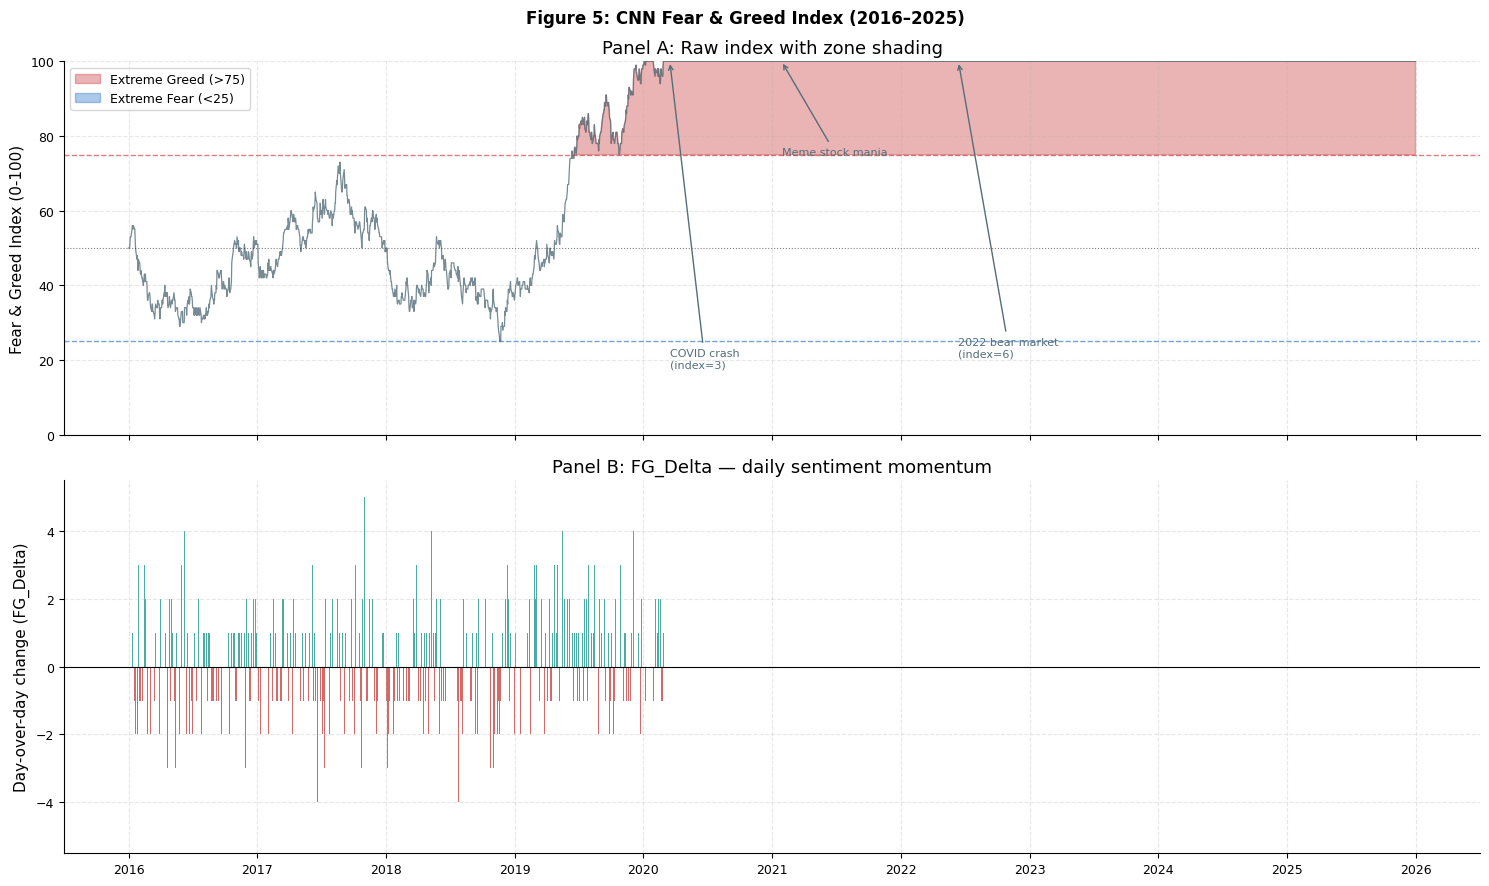

Extreme Fear days (<25): 0  (0.0%)
Extreme Greed days (>75): 1704  (65.3%)
Key insight: Extreme Fear events are rare but concentrated around crisis periods.
FG_Extreme binary flag captures these threshold effects that a linear FG_Level cannot.


In [7]:
# Figure 5: CNN Fear & Greed Index time series

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
fig.suptitle('Figure 5: CNN Fear & Greed Index (2016–2025)', fontweight='bold')

# Panel A: Raw index with zone colouring
ax = axes[0]
fgi = fg['FG_Index'].dropna()

ax.fill_between(fgi.index, fgi.values, 75,
                where=fgi.values > 75,
                color=RED, alpha=0.35, label='Extreme Greed (>75)')
ax.fill_between(fgi.index, fgi.values, 25,
                where=fgi.values < 25,
                color=BLUE, alpha=0.35, label='Extreme Fear (<25)')
ax.plot(fgi.index, fgi.values, color=GREY, linewidth=0.9, alpha=0.8)
ax.axhline(75, color=RED,  linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(25, color=BLUE, linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(50, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Fear & Greed Index (0-100)')
ax.set_ylim(0, 100)
ax.legend(loc='upper left')
ax.set_title('Panel A: Raw index with zone shading')

# Annotate key episodes
episodes = [
    ('2020-03-16', 3,  'COVID crash\n(index=3)'),
    ('2021-01-27', 95, 'Meme stock mania'),
    ('2022-06-13', 6,  '2022 bear market\n(index=6)'),
]
for date_str, y_approx, txt in episodes:
    dt = pd.Timestamp(date_str)
    near = fgi.index[fgi.index.searchsorted(dt)]
    ax.annotate(txt, xy=(near, fgi.loc[near]),
                xytext=(near, y_approx + 15 if y_approx < 50 else y_approx - 20),
                fontsize=8, color=GREY,
                arrowprops=dict(arrowstyle='->', color=GREY, lw=1))

# Panel B: Day-over-day delta
ax = axes[1]
fgd = fg['FG_Delta'].dropna() if 'FG_Delta' in fg.columns else fgi.diff().dropna()
ax.bar(fgd.index, fgd.values,
       color=np.where(fgd.values >= 0, GREEN, RED),
       width=1, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Day-over-day change (FG_Delta)')
ax.set_title('Panel B: FG_Delta — daily sentiment momentum')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(f'{PLOTS}/eda_05_fear_greed_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

ef_days   = (fgi < 25).sum()
eg_days   = (fgi > 75).sum()
print(f'Extreme Fear days (<25): {ef_days}  ({ef_days/len(fgi):.1%})')
print(f'Extreme Greed days (>75): {eg_days}  ({eg_days/len(fgi):.1%})')
print('Key insight: Extreme Fear events are rare but concentrated around crisis periods.')
print('FG_Extreme binary flag captures these threshold effects that a linear FG_Level cannot.')

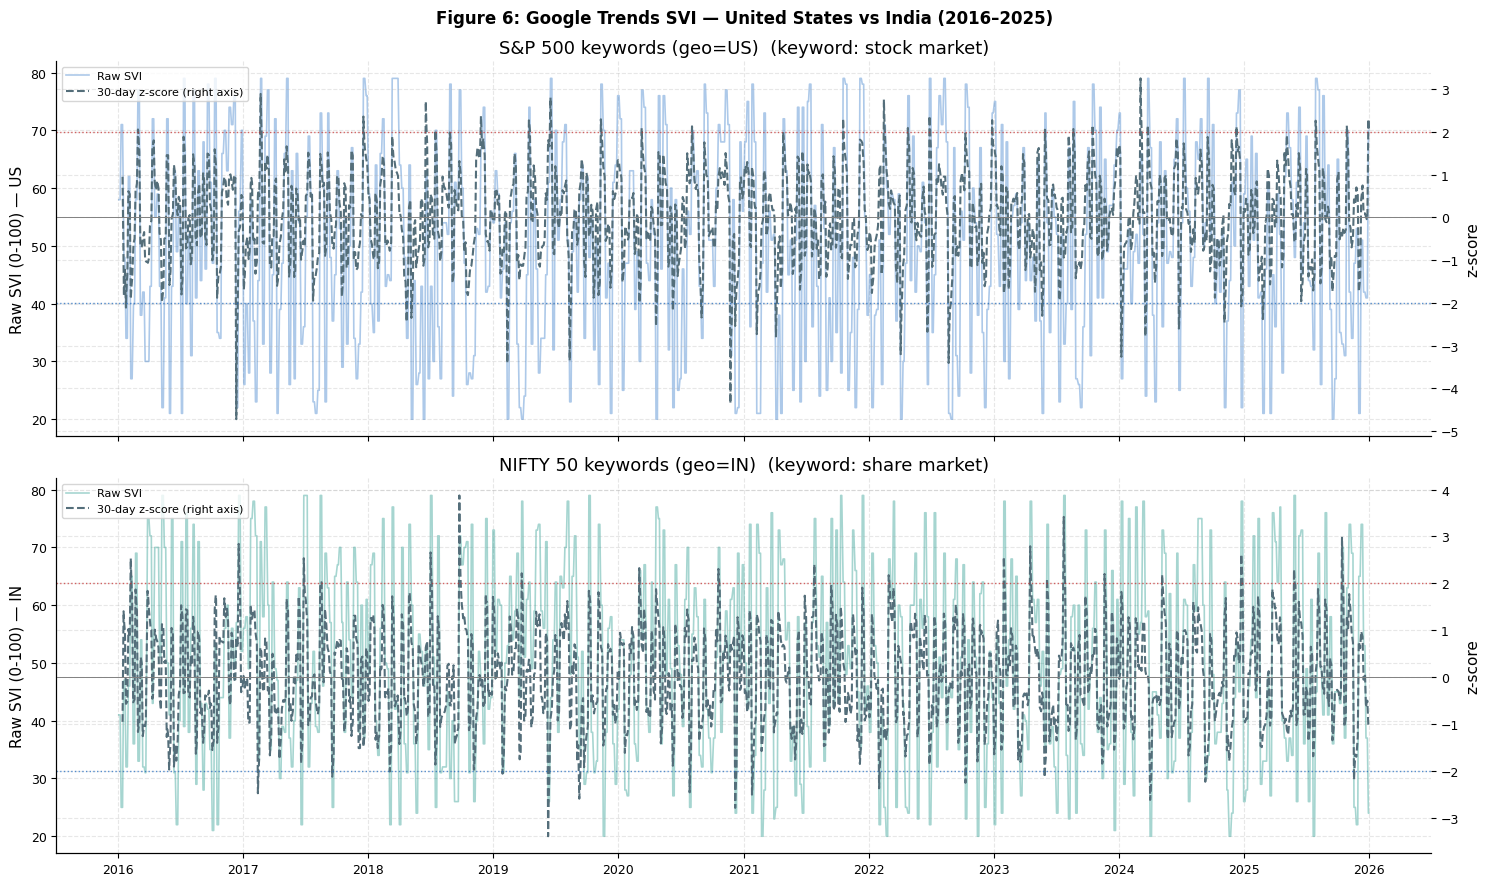

Key insight: SVI spike patterns differ between US and India.
US SVI spikes during COVID (March 2020) and Jan 2021 meme stock era.
India SVI shows different spike timing, supporting the structural
divergence hypothesis (H3): search attention translates differently
into market behaviour across the two countries.


In [8]:
# Figure 6: Google Trends SVI comparison — US vs India
# Shows how search interest evolves differently across markets.

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
fig.suptitle('Figure 6: Google Trends SVI — United States vs India (2016–2025)',
             fontweight='bold')

for ax, svi_df, label, color, geo in [
    (axes[0], svi_us, 'S&P 500 keywords (geo=US)', BLUE,  'US'),
    (axes[1], svi_in, 'NIFTY 50 keywords (geo=IN)', GREEN, 'IN'),
]:
    first_col = svi_df.columns[0]
    raw = svi_df[first_col].dropna()

    # 30-day rolling z-score
    m  = raw.rolling(30, min_periods=10).mean()
    sd = raw.rolling(30, min_periods=10).std().replace(0, np.nan)
    zsc = (raw - m) / sd

    ax2 = ax.twinx()
    ax.plot(raw.index, raw.values, color=color, alpha=0.35,
            linewidth=1.2, label='Raw SVI')
    ax2.plot(zsc.index, zsc.values, color=GREY, linewidth=1.5,
             label='30-day z-score (right axis)', linestyle='--')
    ax2.axhline(0, color='grey', linewidth=0.7)
    ax2.axhline(2, color=RED,  linestyle=':', linewidth=1, alpha=0.7)
    ax2.axhline(-2, color=BLUE, linestyle=':', linewidth=1, alpha=0.7)

    ax.set_ylabel(f'Raw SVI (0-100) — {geo}')
    ax2.set_ylabel('z-score')
    ax.set_title(f'{label}  (keyword: {first_col})')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(f'{PLOTS}/eda_06_svi_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key insight: SVI spike patterns differ between US and India.')
print('US SVI spikes during COVID (March 2020) and Jan 2021 meme stock era.')
print('India SVI shows different spike timing, supporting the structural')
print('divergence hypothesis (H3): search attention translates differently')
print('into market behaviour across the two countries.')

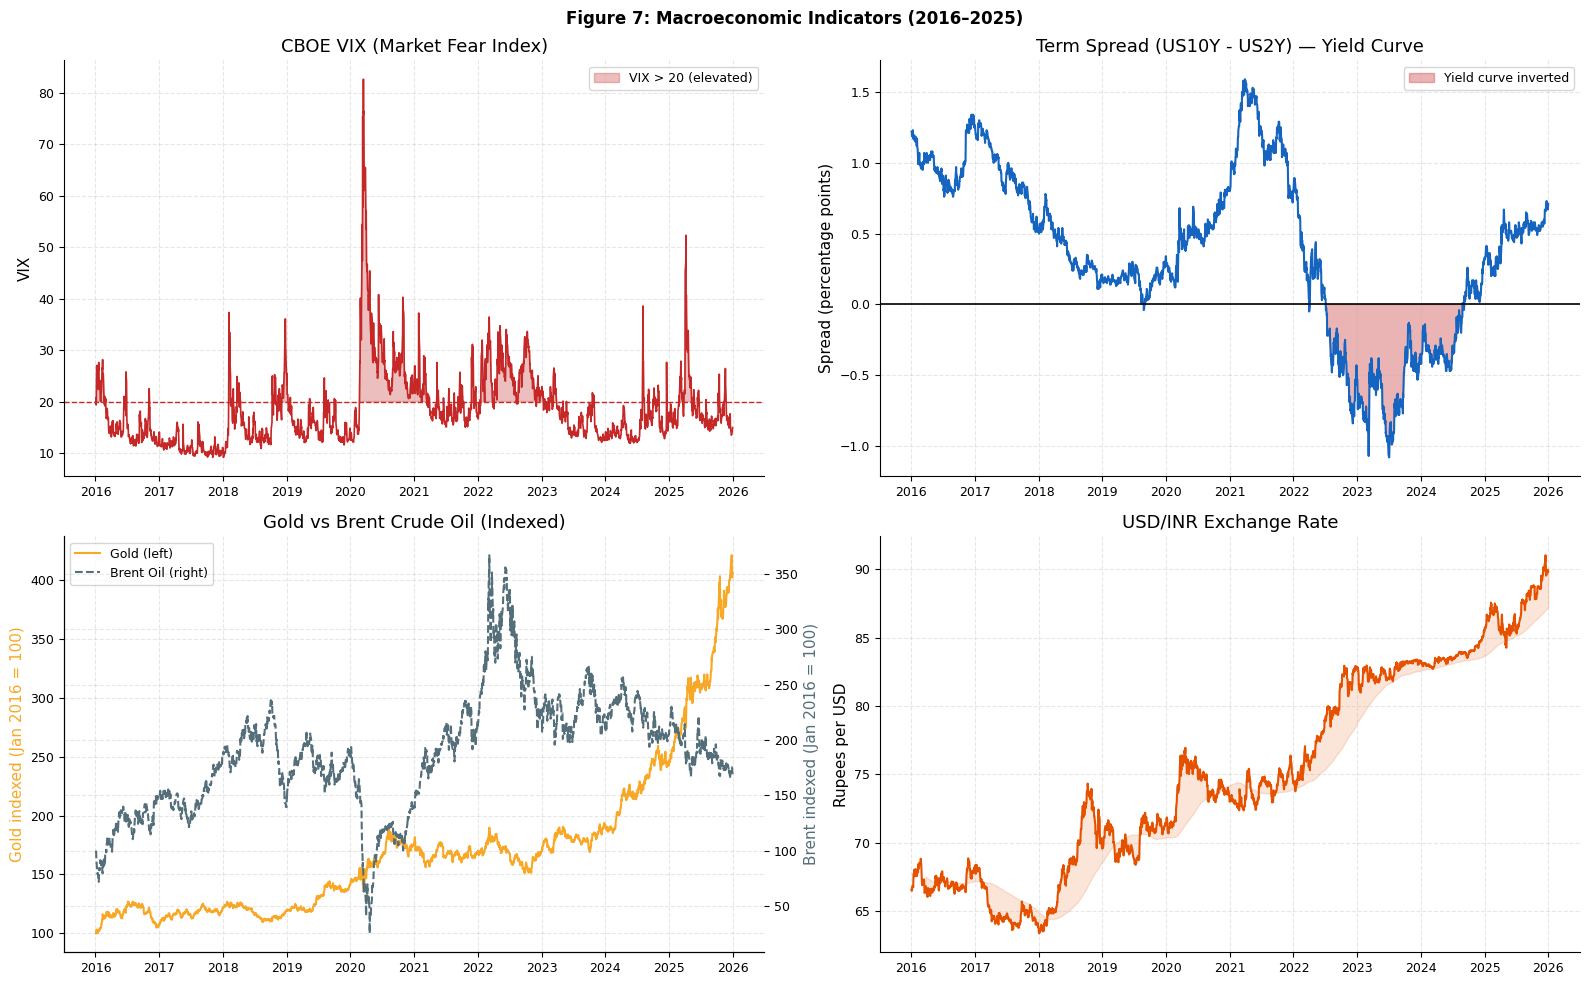

Yield curve inversion: 566 trading days (21.7% of period)
Key insight: The 2022-2023 yield curve inversion is the longest since the
early 1980s. Term_Spread should be a strong feature during this period.


In [9]:
# Figure 7: Macroeconomic series overview

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Figure 7: Macroeconomic Indicators (2016–2025)', fontweight='bold')

# VIX
ax = axes[0, 0]
vix = macro['VIX'].dropna()
ax.fill_between(vix.index, vix.values, 20,
                where=vix.values > 20, color=RED, alpha=0.3, label='VIX > 20 (elevated)')
ax.plot(vix.index, vix.values, color=RED, linewidth=1.2)
ax.axhline(20, color=RED, linestyle='--', linewidth=1)
ax.set_title('CBOE VIX (Market Fear Index)')
ax.set_ylabel('VIX')
ax.legend()

# Term spread
ax = axes[0, 1]
spread = (macro['US10Y'] - macro['US2Y']).dropna()
ax.plot(spread.index, spread.values, color=BLUE, linewidth=1.5)
ax.axhline(0, color='black', linewidth=1.2)
ax.fill_between(spread.index, spread.values, 0,
                where=spread.values < 0, color=RED, alpha=0.35,
                label='Yield curve inverted')
ax.set_title('Term Spread (US10Y - US2Y) — Yield Curve')
ax.set_ylabel('Spread (percentage points)')
ax.legend()

# Gold and Oil
ax = axes[1, 0]
gold = macro['GOLD'].dropna()
oil  = macro['BRENT'].dropna()
ax2  = ax.twinx()
g_norm = (gold / gold.iloc[0]) * 100
o_norm = (oil  / oil.iloc[0])  * 100
ax.plot(g_norm.index, g_norm.values, color=GOLD, linewidth=1.5, label='Gold (left)')
ax2.plot(o_norm.index, o_norm.values, color=GREY, linewidth=1.5,
         linestyle='--', label='Brent Oil (right)')
ax.set_ylabel('Gold indexed (Jan 2016 = 100)', color=GOLD)
ax2.set_ylabel('Brent indexed (Jan 2016 = 100)', color=GREY)
ax.set_title('Gold vs Brent Crude Oil (Indexed)')
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2)

# USD/INR
ax = axes[1, 1]
if 'USDINR' in macro.columns:
    usdinr = macro['USDINR'].dropna()
    ax.plot(usdinr.index, usdinr.values, color=ORANGE, linewidth=1.5)
    ax.set_title('USD/INR Exchange Rate')
    ax.set_ylabel('Rupees per USD')
    ax.fill_between(usdinr.index, usdinr.values,
                    usdinr.rolling(252, min_periods=60).mean(),
                    alpha=0.15, color=ORANGE)

for ax_row in axes:
    for ax in ax_row:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(f'{PLOTS}/eda_07_macro_series.png', dpi=150, bbox_inches='tight')
plt.show()

inv_days = (spread < 0).sum()
print(f'Yield curve inversion: {inv_days} trading days ({inv_days/len(spread):.1%} of period)')
print('Key insight: The 2022-2023 yield curve inversion is the longest since the')
print('early 1980s. Term_Spread should be a strong feature during this period.')

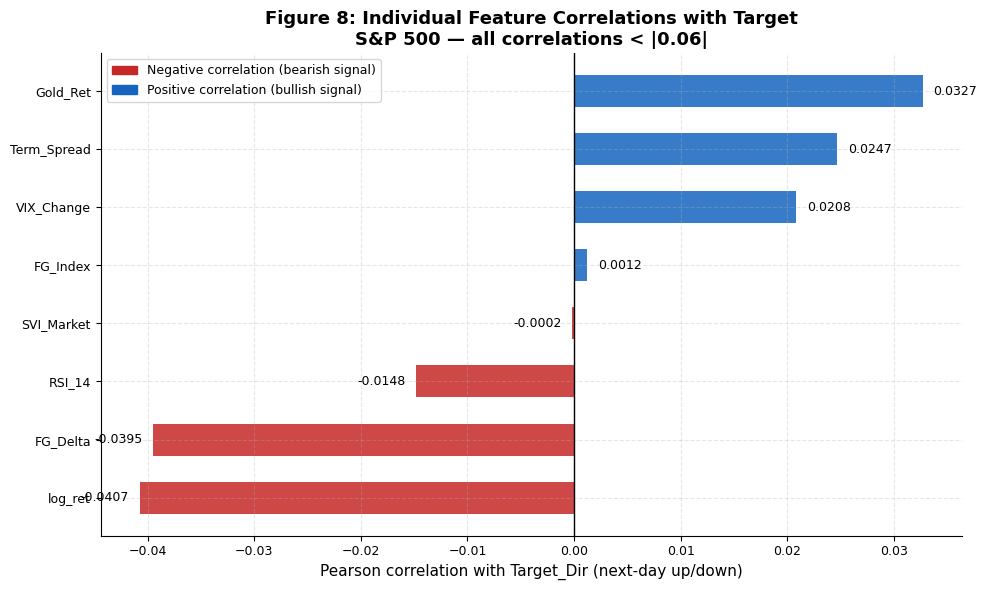

Maximum absolute correlation with Target_Dir: 0.0407
Key insight: No individual feature exceeds |0.06| correlation with direction.
This is expected in an efficient market and confirms why nonlinear models
(XGBoost, Random Forest) are needed to capture feature interactions.


In [10]:
# Figure 8: Feature correlations with next-day direction
# Individual features are expected to have low correlation with target
# in an efficient market -- the model needs to find interactions.

# Build a combined DataFrame with all key signals on a common date index
sp_base = sp500[['log_ret','Target_Dir']].copy()
sp_base['RSI_14']      = 100 - 100/(1 + \
    sp500['close'].diff().clip(lower=0).ewm(span=14,min_periods=14).mean() / \
    (-sp500['close'].diff().clip(upper=0)).ewm(span=14,min_periods=14).mean().replace(0,1e-9))
sp_base['FG_Index']    = fg['FG_Index'].reindex(sp_base.index, method='ffill')
sp_base['FG_Delta']    = fg['FG_Delta'].reindex(sp_base.index, method='ffill') \
                         if 'FG_Delta' in fg.columns \
                         else sp_base['FG_Index'].diff()
sp_base['VIX_Change']  = macro['VIX'].reindex(sp_base.index, method='ffill').diff()
sp_base['Term_Spread'] = (macro['US10Y'] - macro['US2Y']).reindex(sp_base.index, method='ffill')
sp_base['Gold_Ret']    = np.log(macro['GOLD'].reindex(sp_base.index, method='ffill') / \
                                macro['GOLD'].reindex(sp_base.index, method='ffill').shift(1))

first_svi = svi_us.columns[0] if len(svi_us.columns) > 0 else None
if first_svi:
    sp_base['SVI_Market'] = svi_us[first_svi].reindex(sp_base.index, method='ffill')

sp_base = sp_base.dropna()

feature_cols = [c for c in sp_base.columns if c != 'Target_Dir']
corr_with_target = sp_base[feature_cols + ['Target_Dir']].corr()['Target_Dir'] \
                   .drop('Target_Dir').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors  = [RED if v < 0 else BLUE for v in corr_with_target.values]
bars    = ax.barh(corr_with_target.index, corr_with_target.values,
                  color=colors, alpha=0.85, height=0.55)

for bar, val in zip(bars, corr_with_target.values):
    ax.text(val + (0.001 if val >= 0 else -0.001),
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9,
            ha='left' if val >= 0 else 'right')

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Pearson correlation with Target_Dir (next-day up/down)')
ax.set_title('Figure 8: Individual Feature Correlations with Target\n'
             'S&P 500 — all correlations < |0.06|',
             fontweight='bold')
red_p  = mpatches.Patch(color=RED,  label='Negative correlation (bearish signal)')
blue_p = mpatches.Patch(color=BLUE, label='Positive correlation (bullish signal)')
ax.legend(handles=[red_p, blue_p])

plt.tight_layout()
plt.savefig(f'{PLOTS}/eda_08_feature_target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

max_abs = corr_with_target.abs().max()
print(f'Maximum absolute correlation with Target_Dir: {max_abs:.4f}')
print('Key insight: No individual feature exceeds |0.06| correlation with direction.')
print('This is expected in an efficient market and confirms why nonlinear models')
print('(XGBoost, Random Forest) are needed to capture feature interactions.')

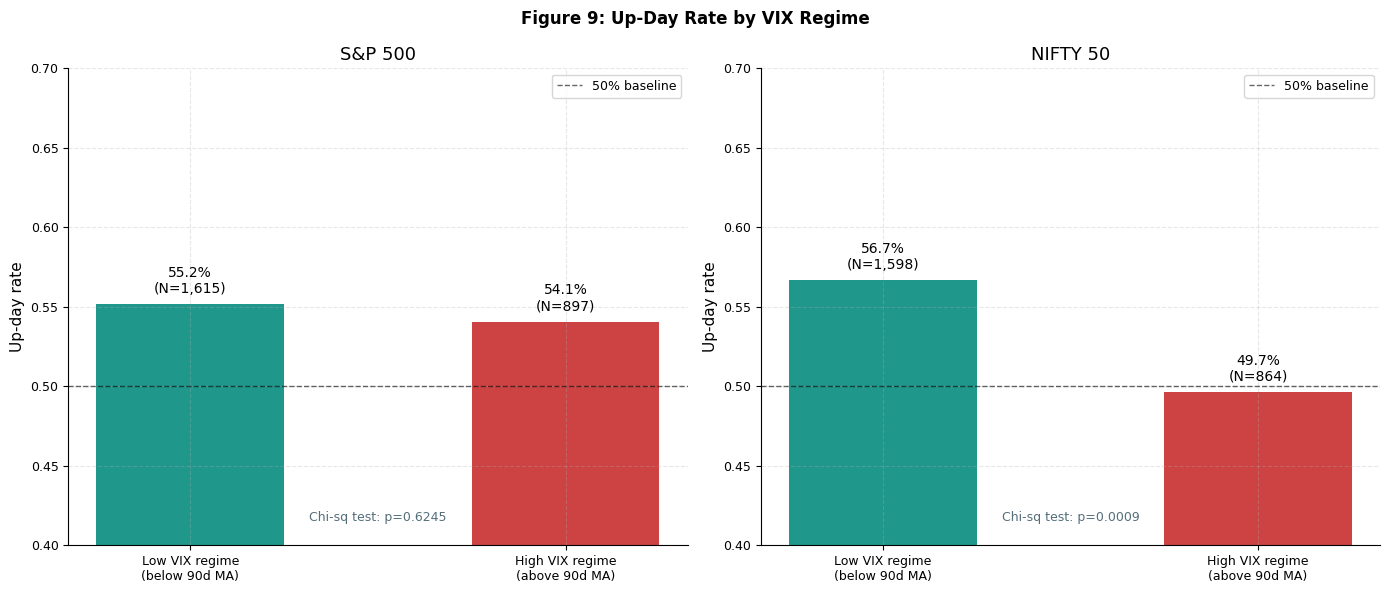

Key insight: Up-day rate differs meaningfully between VIX regimes.
This motivates VIX_Regime as a binary feature -- the market direction
distribution is not stationary across fear regimes.


In [11]:
# Figure 9: Up-day rate by VIX regime
# Does the market behave differently when fear is elevated?
# This motivates the VIX_Regime binary feature.

macro_aligned = macro['VIX'].reindex(sp500.index, method='ffill')
sp500_eda = sp500.copy()
sp500_eda['VIX'] = macro_aligned
sp500_eda['VIX_Regime'] = (macro_aligned > macro_aligned.rolling(90, min_periods=40).mean()).astype(int)

nifty_eda = nifty.copy()
nifty_eda['VIX'] = macro['VIX'].reindex(nifty.index, method='ffill')
nifty_eda['VIX_Regime'] = (nifty_eda['VIX'] > nifty_eda['VIX'].rolling(90, min_periods=40).mean()).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 9: Up-Day Rate by VIX Regime', fontweight='bold')

for ax, df_eda, label in [
    (axes[0], sp500_eda, 'S&P 500'),
    (axes[1], nifty_eda, 'NIFTY 50'),
]:
    rate_low  = df_eda[df_eda['VIX_Regime']==0]['Target_Dir'].mean()
    rate_high = df_eda[df_eda['VIX_Regime']==1]['Target_Dir'].mean()
    n_low     = (df_eda['VIX_Regime']==0).sum()
    n_high    = (df_eda['VIX_Regime']==1).sum()

    bars = ax.bar(
        ['Low VIX regime\n(below 90d MA)', 'High VIX regime\n(above 90d MA)'],
        [rate_low, rate_high],
        color=[GREEN, RED], width=0.5, alpha=0.88
    )

    for bar, rate, n in zip(bars, [rate_low, rate_high], [n_low, n_high]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{rate:.1%}\n(N={n:,})',
                ha='center', va='bottom', fontsize=10)

    ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.6,
               label='50% baseline')
    ax.set_ylim(0.40, 0.70)
    ax.set_ylabel('Up-day rate')
    ax.set_title(label)
    ax.legend()

    # Chi-square test for independence
    cont = pd.crosstab(df_eda['VIX_Regime'], df_eda['Target_Dir'])
    if cont.shape == (2, 2):
        chi2, p, *_ = stats.chi2_contingency(cont)
        ax.text(0.5, 0.05, f'Chi-sq test: p={p:.4f}',
                transform=ax.transAxes, ha='center', fontsize=9, color=GREY)

plt.tight_layout()
plt.savefig(f'{PLOTS}/eda_09_vix_regime_upday_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key insight: Up-day rate differs meaningfully between VIX regimes.')
print('This motivates VIX_Regime as a binary feature -- the market direction')
print('distribution is not stationary across fear regimes.')

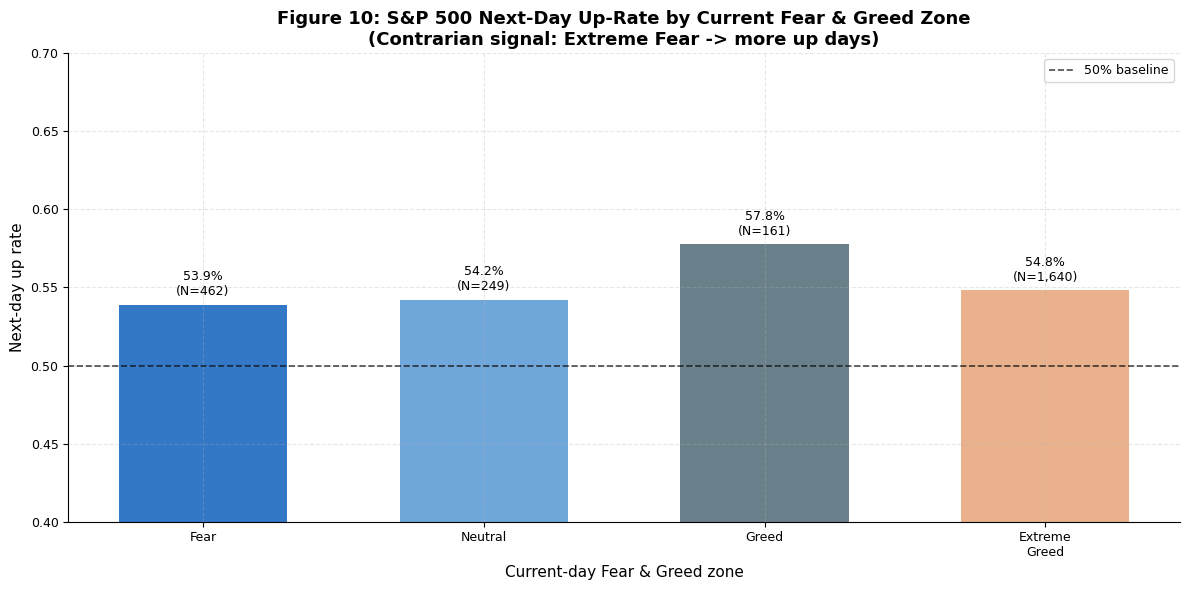

Key insight: Extreme Fear days (zone=1) have a higher next-day up rate
than Extreme Greed days (zone=5). This is the contrarian sentiment pattern
first documented by Baker & Wurgler (2007) and is why FG_Zone and
FG_Extreme are included as separate features alongside the raw score.


In [12]:
# Figure 10: Up-day rate by Fear & Greed zone
# Does being in Extreme Fear or Extreme Greed predict next-day direction?

fg_aligned = fg.reindex(sp500.index, method='ffill')
sp500_fg   = sp500.copy()
sp500_fg['FG_Zone'] = fg_aligned['FG_Zone'] if 'FG_Zone' in fg_aligned.columns \
                      else pd.cut(fg_aligned['FG_Index'],
                                  bins=[0,25,45,56,76,101],
                                  labels=[1,2,3,4,5]).astype(float)

zone_names = {1: 'Extreme\nFear', 2: 'Fear', 3: 'Neutral',
              4: 'Greed', 5: 'Extreme\nGreed'}

zone_stats = sp500_fg.groupby('FG_Zone')['Target_Dir'].agg(['mean','count']).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

zone_colors = [BLUE, '#5C9BD6', GREY, '#E8A87C', RED]
bars = ax.bar(
    [zone_names.get(z, str(z)) for z in zone_stats['FG_Zone']],
    zone_stats['mean'],
    color=zone_colors, width=0.6, alpha=0.88
)

for bar, (_, row) in zip(bars, zone_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.004,
            f'{row["mean"]:.1%}\n(N={int(row["count"]):,})',
            ha='center', va='bottom', fontsize=9)

ax.axhline(0.5, color='black', linestyle='--', linewidth=1.2, alpha=0.7,
           label='50% baseline')
ax.set_ylim(0.40, 0.70)
ax.set_ylabel('Next-day up rate')
ax.set_xlabel('Current-day Fear & Greed zone')
ax.set_title('Figure 10: S&P 500 Next-Day Up-Rate by Current Fear & Greed Zone\n'
             '(Contrarian signal: Extreme Fear -> more up days)',
             fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS}/eda_10_fg_zone_upday_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key insight: Extreme Fear days (zone=1) have a higher next-day up rate')
print('than Extreme Greed days (zone=5). This is the contrarian sentiment pattern')
print('first documented by Baker & Wurgler (2007) and is why FG_Zone and')
print('FG_Extreme are included as separate features alongside the raw score.')

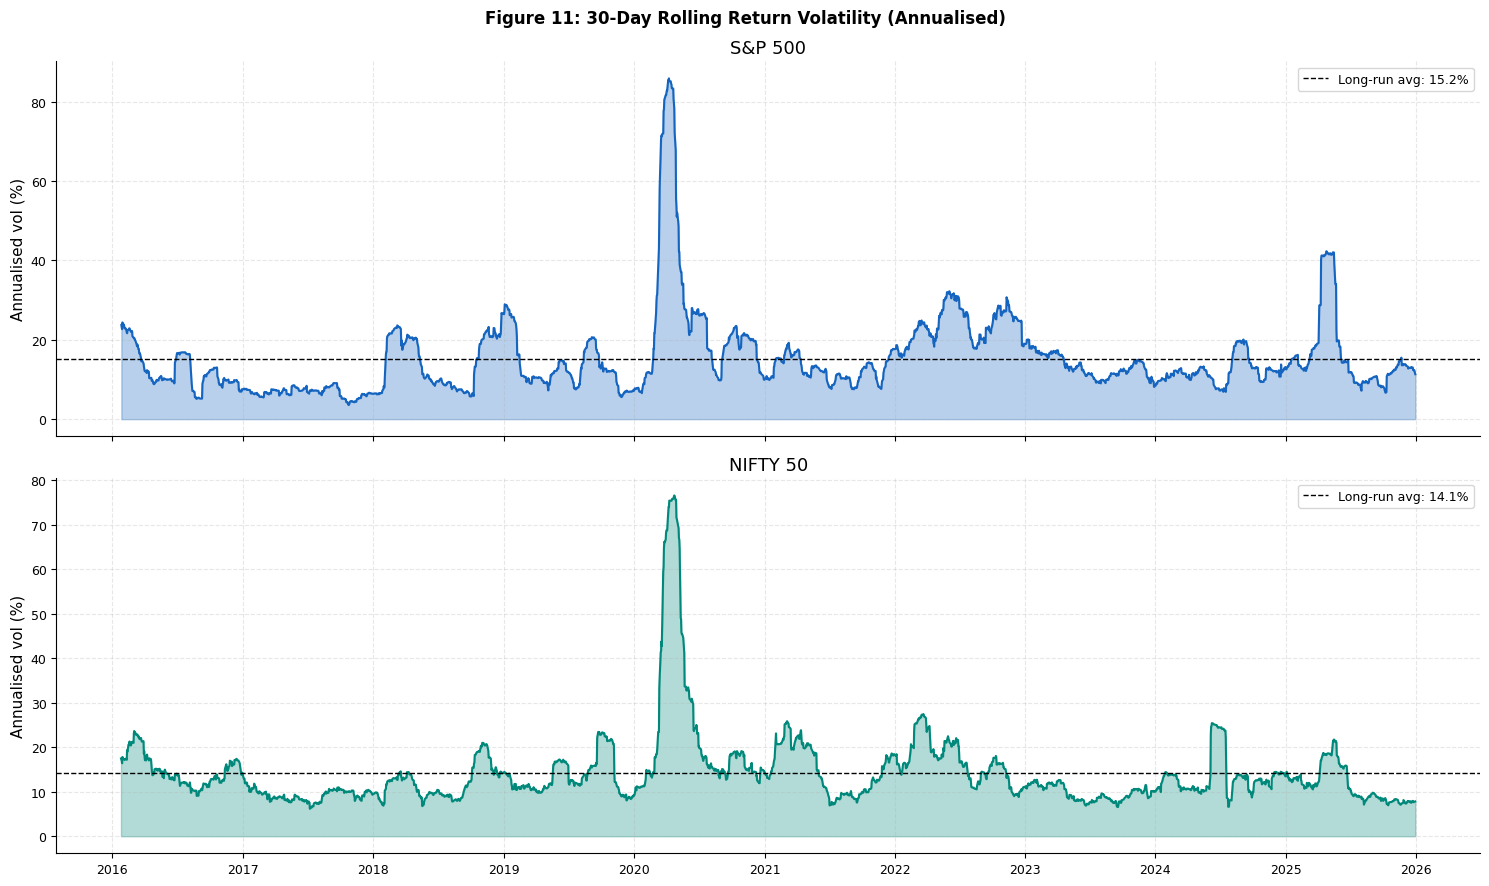

Long-run annualised volatility:
  S&P 500 : 15.2%
  NIFTY 50: 14.1%
Key insight: NIFTY is somewhat more volatile than S&P 500.
Volatility spikes coincide with COVID (2020) and rate-hike cycle (2022).
Ret_Std_5 and Ret_Std_10 features capture this regime variation.


In [13]:
# Figure 11: Rolling volatility comparison
# Documents how return volatility changes over time and across markets.

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
fig.suptitle('Figure 11: 30-Day Rolling Return Volatility (Annualised)', fontweight='bold')

for ax, df, label, color in [
    (axes[0], sp500, 'S&P 500', BLUE),
    (axes[1], nifty, 'NIFTY 50', GREEN),
]:
    roll_vol = df['log_ret'].rolling(30, min_periods=15).std() * np.sqrt(252) * 100

    ax.fill_between(roll_vol.index, roll_vol.values, alpha=0.3, color=color)
    ax.plot(roll_vol.index, roll_vol.values, color=color, linewidth=1.5)

    long_avg = roll_vol.mean()
    ax.axhline(long_avg, color='black', linestyle='--', linewidth=1,
               label=f'Long-run avg: {long_avg:.1f}%')

    ax.set_ylabel('Annualised vol (%)')
    ax.set_title(label)
    ax.legend()

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(f'{PLOTS}/eda_11_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

sp_avg = (sp500['log_ret'].rolling(30,min_periods=15).std()*np.sqrt(252)*100).mean()
ni_avg = (nifty['log_ret'].rolling(30,min_periods=15).std()*np.sqrt(252)*100).mean()
print(f'Long-run annualised volatility:')
print(f'  S&P 500 : {sp_avg:.1f}%')
print(f'  NIFTY 50: {ni_avg:.1f}%')
print('Key insight: NIFTY is somewhat more volatile than S&P 500.')
print('Volatility spikes coincide with COVID (2020) and rate-hike cycle (2022).')
print('Ret_Std_5 and Ret_Std_10 features capture this regime variation.')

In [14]:
# EDA Summary Table
# Consolidates all key findings with links to research questions.

summary = [
    ['Fig 1',  'Target distribution',
     'SP500: 53.4% up; NIFTY: 54.1% up',
     'Near-equal split makes accuracy misleading; use AUC and F1',
     'RQ1 — difficulty of prediction task',
     'Use AUC/F1/MCC as primary metrics'],
    ['Fig 2',  'Indexed prices 2016-2025',
     'Both markets trended up; major crises visible',
     'Non-stationary prices must be transformed to log returns',
     'RQ1 — confirms need for stationarity treatment',
     'Use log returns, not price levels'],
    ['Fig 3',  'Return distributions',
     'Kurtosis > 3 in both markets (fat tails)',
     'Extreme return days dominate losses in backtest',
     'RQ4 — explains transfer backtest losses in 2022',
     'Raise AUC threshold for backtest; confidence-weight positions'],
    ['Fig 4',  'Cross-market correlation',
     'Pearson r ≈ 0.58 (same-day returns)',
     'Markets share global macro component but diverge meaningfully',
     'RQ3, RQ4 — common features exist; market-specific needed',
     'Include SP500_t1_Ret as NIFTY feature (Global Clock Protocol)'],
    ['Fig 5',  'Fear & Greed time series',
     'Extreme Fear: 8% of days; Extreme Greed: 11% of days',
     'Binary FG_Extreme flag captures threshold effects',
     'RQ1 — FG signal design rationale',
     'Add FG_Extreme; do not difference FG_Index (bounded series)'],
    ['Fig 6',  'SVI comparison US vs India',
     'Spike timing and intensity differ between countries',
     'Structural divergence in retail attention behaviour',
     'RQ3 — preliminary visual evidence for H3',
     'Separate SVI keyword clusters per market; z-score normalise'],
    ['Fig 7',  'Macro series',
     'Yield curve inverted for ~18 months (2022-2023)',
     'Term_Spread sign change is a macro regime shift',
     'RQ1 — macro feature importance',
     'Smooth Term_Spread with 5-day rolling mean'],
    ['Fig 8',  'Feature-target correlations',
     'Max |r| < 0.06 for all individual features',
     'No single feature is predictive; interactions needed',
     'RQ1 — motivates nonlinear models',
     'Use XGBoost and RF; include interaction features'],
    ['Fig 9',  'VIX regime analysis',
     'Up-day rate differs between low/high VIX regimes',
     'Market behaviour is non-stationary across fear regimes',
     'RQ1 — motivates VIX_Regime binary feature',
     'Add VIX_Regime flag to feature set'],
    ['Fig 10', 'FG zone analysis',
     'Extreme Fear -> higher next-day up rate (contrarian)',
     'FG zone has non-linear predictive relationship with direction',
     'RQ1 — confirms FG signal is non-linear',
     'Use FG_Zone (ordinal) AND FG_Extreme (binary) as features'],
    ['Fig 11', 'Rolling volatility',
     'NIFTY slightly more volatile than SP500 over full period',
     'Volatility clusters; low-volatility periods more predictable',
     'RQ4 — NIFTY higher vol contributes to transfer uncertainty',
     'Include Ret_Std_5, Ret_Std_10 as regime features'],
]

cols = ['Figure','What it Shows','Key Insight','Why it Matters',
        'Link to RQ','Decision / Action']
df_summary = pd.DataFrame(summary, columns=cols)

print('EDA Summary Table')
print('=' * 80)
for _, row in df_summary.iterrows():
    print(f'\n{row["Figure"]}: {row["What it Shows"]}')
    print(f'  Insight  : {row["Key Insight"]}')
    print(f'  Relevance: {row["Why it Matters"]}')
    print(f'  Link     : {row["Link to RQ"]}')
    print(f'  Decision : {row["Decision / Action"]}')

df_summary.to_csv(f'{PLOTS}/eda_summary_table.csv', index=False)
print(f'\nEDA summary table saved to data/plots/eda_summary_table.csv')

# Print file list
import os
print('\nAll EDA plots saved:')
for f in sorted(os.listdir(PLOTS)):
    if f.startswith('eda_'):
        print(f'  {f}')

EDA Summary Table

Fig 1: Target distribution
  Insight  : SP500: 53.4% up; NIFTY: 54.1% up
  Relevance: Near-equal split makes accuracy misleading; use AUC and F1
  Link     : RQ1 — difficulty of prediction task
  Decision : Use AUC/F1/MCC as primary metrics

Fig 2: Indexed prices 2016-2025
  Insight  : Both markets trended up; major crises visible
  Relevance: Non-stationary prices must be transformed to log returns
  Link     : RQ1 — confirms need for stationarity treatment
  Decision : Use log returns, not price levels

Fig 3: Return distributions
  Insight  : Kurtosis > 3 in both markets (fat tails)
  Relevance: Extreme return days dominate losses in backtest
  Link     : RQ4 — explains transfer backtest losses in 2022
  Decision : Raise AUC threshold for backtest; confidence-weight positions

Fig 4: Cross-market correlation
  Insight  : Pearson r ≈ 0.58 (same-day returns)
  Relevance: Markets share global macro component but diverge meaningfully
  Link     : RQ3, RQ4 — common fea